## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import scipy.stats as stats
import matplotlib.pyplot as plt
import pyEDM

import session_info
session_info.show()

## Define Functions

In [14]:
def simplex_wrapper(
    dataFrame=None,
    columns='',
    target='',
    lib='',
    pred='',
    E=0,
    Tp=1,
    knn=0,
    tau=-1,
    exclusionRadius=0,
    embedded=False,
    validLib=None,
    noTime=False,
    generateSteps=0,
    generateConcat=False,
    verbose=False,
    showPlot=None,
    ignoreNan=True,        
    handleNan=False,        # automatically handles missing values if True (so you don't have to manually use validLib)
    returnObject=False,
    metric='rho',
    sig=0.05,
    figsize=(10,3.5),
    decimals=None,
    plot_kwargs=None,       # Extra kwargs passed to ax.plot(), e.g. {'linestyle': '.', 'color': 'red'}
):
    """Wrapper for pyEDM Simplex function.

    E and tau can be given as integers (in which case it simply returns
    the Simplex output), or as a list (in which case it returns a table
    of E/tau prediction skill and their significance against the constant
    predictor).

    Args:
        dataFrame: Input DataFrame.
        columns: Predictor column name(s).
        target: Target column name.
        lib: Library indices string, e.g. '1 100'.
        pred: Prediction indices string, e.g. '1 100'.
        E: Embedding dimension — int or list of ints.
        Tp: Prediction horizon.
        knn: Number of nearest neighbours (0 = E+1).
        tau: Embedding lag — int or list of ints.
        exclusionRadius: Temporal exclusion radius.
        embedded: Whether dataFrame is already embedded.
        validLib: Boolean vector marking valid library rows.
        noTime: If True, treat first column as data, not time.
        generateSteps: Number of generative steps.
        generateConcat: If True, concatenate generative output.
        verbose: Print progress information.
        showPlot: Plot results.
        ignoreNan: Ignore NaN values.
        returnObject: Return the full Simplex object.
        metric: Skill metric for E/tau comparison (default 'rho').
        sig: Significance level for hypothesis tests (default 0.01).
        figsize: Figure size for plots; None uses the default.
        decimals: Decimal places in output table; None uses the default.

    Returns:
        dict: When E and tau are both integers:
                {'Predictions': <simplex output>,
                 'Summary Statistics': <statistics>}
              When either is a list: the output of E_vs_tau().
    """

    # Default behavior
    if validLib is None:
        validLib = []
    if plot_kwargs is None:
        plot_kwargs = {'style': '.-'}

    # showPlot default is True if E/tau are lists; False if E/tau are integers
    if showPlot is None:
        showPlot = not (isinstance(E, int) and isinstance(tau, int))

    # Use entire time series as lib/pred if none are specified
    if lib == '':
        lib = f'1 {len(dataFrame)}'
    if pred == '':
        pred = f'1 {len(dataFrame)}'

    # If E and tau are both integers: return Simplex output + summary stats
    if isinstance(E, int) and isinstance(tau, int):

        # Optional: add automatic handling of missing values using validLib
        # validLib = True where embedding vectors and target(t+Tp) are not NaN
        if handleNan == True:
            if embedded == False:
                embedding = pyEDM.Embed(dataFrame=dataFrame, E=E, tau=tau, columns=columns)
            else:
                embedding = dataFrame[columns]
            valid_embed = embedding.notna().all(axis=1)
            valid_target = dataFrame[target].shift(-Tp).notna()
            validLib = valid_embed & valid_target

        # Run pyEDM Simplex function
        out = pyEDM.Simplex(
            dataFrame=dataFrame,
            columns=columns,
            target=target,
            lib=lib,
            pred=pred,
            E=E,
            Tp=Tp,
            knn=knn,
            tau=tau,
            exclusionRadius=exclusionRadius,
            embedded=embedded,
            validLib=validLib,
            noTime=noTime,
            generateSteps=generateSteps,
            generateConcat=generateConcat,
            verbose=verbose,
            showPlot=False,                  # Suppress pyEDM's native plot
            ignoreNan=ignoreNan,
            returnObject=returnObject,
        )

        # Returns Simplex object if returnObject = True; does not calculate summary statistics or make plot
        if returnObject == True:
            return out
        
        statistics = calculate_summary_statistics(out, columns, target, Tp)

        # Improved default plot
        if showPlot:
            if decimals is None:
                decimals = 3
            rho = statistics.loc['rho', 'Simplex']
            fig, ax = plt.subplots(figsize=figsize)
            out.plot(ax=ax, x='Time', y=['Observations', 'Predictions'], **plot_kwargs)
            ax.set_xlabel('Time')
            ax.set_ylabel(target)
            ax.set_title(f'Simplex Predictions for {target} (Tp={Tp}, E={E}, τ={tau}) \nρ = {rho:.{decimals}f}')
            ax.legend()
            plt.tight_layout()
            plt.show()
                    
        output = {'Predictions': out, 'Summary Statistics': statistics}

    # If E or tau is a list: run E_vs_tau grid search
    else:
        if isinstance(E, int) and isinstance(tau, list):
            E = [E]
        elif isinstance(E, list) and isinstance(tau, int):
            tau = [tau]
        # If both are already lists, no conversion is needed
        output = E_vs_tau(
            dataFrame=dataFrame,
            columns=columns,
            target=target,
            lib=lib,
            pred=pred,
            E=E,
            Tp=Tp,
            knn=knn,
            tau=tau,
            exclusionRadius=exclusionRadius,
            embedded=embedded,
            validLib=validLib,
            noTime=noTime,
            generateSteps=generateSteps,
            generateConcat=generateConcat,
            verbose=verbose,
            showPlot=showPlot,
            ignoreNan=ignoreNan,
            returnObject=returnObject,
            metric=metric,
            sig=sig,
            figsize=figsize,
            decimals=decimals,
        )

    return output

In [23]:
def fisher_z_test(rho_1, rho_2, n_1, n_2, sig):
    """Test if rho_1 is significantly larger than rho_2 using Fisher's z-transformation."""

    rho_1 = np.clip(rho_1, -0.9999, 0.9999)
    rho_2 = np.clip(rho_2, -0.9999, 0.9999)
    
    z_1 = 0.5 * np.log((1 + rho_1) / (1 - rho_1))
    z_2 = 0.5 * np.log((1 + rho_2) / (1 - rho_2))

    se = np.sqrt((1 / (n_1 - 3)) + (1 / (n_2 - 3)))
    z = (z_1 - z_2) / se
    p_value = 1 - stats.norm.cdf(z)

    return int(p_value < sig)


def one_tailed_t_test(list_1, list_2, sig):
    """Test if the mean of list_1 is significantly larger than the mean of list_2 using a one-tailed t-test."""
    
    u_1, u_2 = np.mean(list_1), np.mean(list_2)
    sd_1, sd_2 = np.std(list_1), np.std(list_2)
    n_1, n_2 = len(list_1), len(list_2)

    se = np.sqrt((sd_1**2 / n_1) + (sd_2**2 / n_2))
    t = (u_2 - u_1) / se

    numerator = ((sd_1**2 / n_1) + (sd_2**2 / n_2)) ** 2
    denominator = ((sd_1**2 / n_1) ** 2 / (n_1 - 1)) + ((sd_2**2 / n_2) ** 2 / (n_2 - 1))
    dof = numerator / denominator

    p_value = stats.t.cdf(t, dof)

    return int(p_value < sig)


def calculate_summary_statistics(results, columns, target, Tp):
    """Calculate summary statistics for Simplex and constant predictor."""
    summary_statistics = pd.DataFrame(
        None,
        index=['rho', 'MAE', 'RMSE', '% Correct Sign', 'N Predicted'],
        columns=['Simplex', 'Constant Predictor'],
    )

    df = results.copy()
    df['Constant Predictor'] = df['Observations'].shift(Tp)

    # Correlation
    summary_statistics.loc['rho', 'Simplex'] = df.corr().loc['Observations', 'Predictions']
    summary_statistics.loc['rho', 'Constant Predictor'] = df.corr().loc['Observations', 'Constant Predictor']

    # MAE
    summary_statistics.loc['MAE', 'Simplex'] = np.abs(df['Observations'] - df['Predictions']).mean()
    summary_statistics.loc['MAE', 'Constant Predictor'] = np.abs(df['Observations'] - df['Constant Predictor']).mean()

    # RMSE
    summary_statistics.loc['RMSE', 'Simplex'] = np.sqrt(((df['Observations'] - df['Predictions']) ** 2).mean())
    summary_statistics.loc['RMSE', 'Constant Predictor'] = np.sqrt(((df['Observations'] - df['Constant Predictor']) ** 2).mean())

    # % Correct Sign
    df['ObsSign'] = np.sign(df['Observations'].diff())
    df['PredSign_Simplex'] = np.sign(df['Predictions'].diff())
    df['PredSign_Constant_Predictor'] = np.sign(df['Constant Predictor'].diff())

    valid = ~df['ObsSign'].isnull()
    correct_simplex = ((df['ObsSign'] == df['PredSign_Simplex']) & valid).sum()
    correct_const = ((df['ObsSign'] == df['PredSign_Constant_Predictor']) & valid).sum()
    total_predictions = valid.sum()

    summary_statistics.loc['% Correct Sign', 'Simplex'] = (correct_simplex / total_predictions) * 100
    summary_statistics.loc['% Correct Sign', 'Constant Predictor'] = (correct_const / total_predictions) * 100

    # N Predicted (number of Observed/Predicted pairs)
    summary_statistics.loc['N Predicted', 'Simplex'] = len(df[['Observations', 'Predictions']].dropna())
    summary_statistics.loc['N Predicted', 'Constant Predictor'] = len(df[['Observations', 'Constant Predictor']].dropna())

    # If cross-mapping, do not return constant predictor values
    is_cross_mapping = target not in columns
    if is_cross_mapping:
        summary_statistics.loc[:,'Constant Predictor'] = np.nan

    return summary_statistics


def E_vs_tau(
    dataFrame=None,
    columns='',
    target='',
    lib='',
    pred='',
    E=0,
    Tp=1,
    knn=0,
    tau=-1,
    exclusionRadius=0,
    embedded=False,
    validLib=None,
    noTime=False,
    generateSteps=0,
    generateConcat=False,
    verbose=False,
    showPlot=False,
    ignoreNan=True,
    returnObject=False,
    metric='rho',
    sig=0.01,
    figsize=None,
    decimals=None,
):
    """Compute Simplex prediction skill across a grid of E and tau values.

    Args:
        dataFrame: Input DataFrame.
        columns: Predictor column name(s).
        target: Target column name.
        lib: Library indices string.
        pred: Prediction indices string.
        E: List of embedding dimensions to test.
        Tp: Prediction horizon.
        knn: Number of nearest neighbours (0 = E+1).
        tau: List of embedding lags to test.
        exclusionRadius: Temporal exclusion radius.
        embedded: Whether dataFrame is already embedded.
        validLib: Boolean vector marking valid library rows.
        noTime: If True, treat first column as data, not time.
        generateSteps: Number of generative steps.
        generateConcat: If True, concatenate generative output.
        verbose: Print progress information.
        showPlot: Plot results (unused internally; plot always shown).
        ignoreNan: Ignore NaN values.
        returnObject: Return the full Simplex object.
        metric: Skill metric — 'rho' or 'MAE' (default 'rho').
        sig: Significance level for hypothesis tests (default 0.01).
        figsize: Matplotlib figure size tuple; None uses the default.
        decimals: Decimal places in heatmap annotations; None defaults to 4.

    Returns:
        dict: {
            'E_vs_tau': DataFrame of metric values,
            'significance': DataFrame of significance flags (1 = significant)
        }
    """
    if validLib is None:
        validLib = []

    # Determine if we are cross-mapping (determines whether we compare with the constant predictor)
    is_cross_mapping = target not in columns
    
    E_tau = pd.DataFrame(index=tau, columns=E)
    E_tau_sig = pd.DataFrame(index=tau, columns=E)

    for _E_ in E:
        for _tau_ in tau:
            s = simplex_wrapper(
                dataFrame=dataFrame,
                columns=columns,
                target=target,
                lib=lib,
                pred=pred,
                E=_E_,
                Tp=Tp,
                knn=knn,
                tau=_tau_,
                exclusionRadius=exclusionRadius,
                embedded=embedded,
                validLib=validLib,
                noTime=noTime,
                generateSteps=generateSteps,
                generateConcat=generateConcat,
                verbose=verbose,
                showPlot=False,
                ignoreNan=ignoreNan,
                returnObject=returnObject,
            )
            simplex_metric = s['Summary Statistics']['Simplex'][metric]
            n_simplex = s['Summary Statistics']['Simplex']['N Predicted']
            const_metric = s['Summary Statistics']['Constant Predictor'][metric]
            n_const = s['Summary Statistics']['Constant Predictor']['N Predicted']

            if is_cross_mapping:     # No equivalent to constant predictor for cross-mapping
                significant = None
            elif metric == 'rho':
                significant = fisher_z_test(simplex_metric, const_metric, n_simplex, n_const, sig)
            elif metric == 'MAE':
                abs_error_simplex = np.abs(
                    s['Predictions']['Observations'] - s['Predictions']['Predictions']
                )
                abs_error_const_df = s['Predictions'].copy()
                abs_error_const_df['Constant Predictor'] = abs_error_const_df['Observations'].shift(Tp)
                abs_error_const = np.abs(
                    abs_error_const_df['Observations'] - abs_error_const_df['Constant Predictor']
                )
                significant = one_tailed_t_test(abs_error_const, abs_error_simplex, sig)
            else:
                raise NotImplementedError(f"Significance test not implemented for metric '{metric}'.")

            E_tau.at[_tau_, _E_] = simplex_metric
            E_tau_sig.at[_tau_, _E_] = significant

    E_tau = E_tau.apply(pd.to_numeric, errors='coerce')
    E_tau_sig = E_tau_sig.apply(pd.to_numeric, errors='coerce')

    # Plot
    if showPlot == True:
        cmap = 'viridis' if metric == 'rho' else 'viridis_r'
        metric_title = 'ρ' if metric == 'rho' else 'MAE'
        decimals = decimals if decimals is not None else 4
    
        fig = plt.figure(figsize=figsize)  # figsize=None uses matplotlib default
    
        has_sig_points = np.any(E_tau_sig == 1)
        if has_sig_points:
            vmin = np.nanmin(E_tau[E_tau_sig == 1])
            vmax = np.nanmax(E_tau[E_tau_sig == 1])
        else:
            vmin = np.nanmin(E_tau.values)
            vmax = np.nanmax(E_tau.values)
    
        sns.heatmap(
            E_tau,
            annot=True,
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            fmt=f'.{decimals}f',
            cbar_kws={'label': metric_title},
        )
        all_nan_sig = np.all(np.isnan(E_tau_sig.values.astype(float)))
        all_significant = np.all(E_tau_sig == 1)
        if not all_significant and not all_nan_sig:
            sns.heatmap(
                E_tau_sig,
                mask=E_tau_sig,
                cbar=False,
                annot=False,
                cmap=sns.color_palette(['darkgray']),
            )
        plt.title(f'{metric_title} Values for Es and taus (Tp = {Tp}, metric = {metric})')
        plt.xlabel('E')
        plt.ylabel('tau')
        plt.show()

    return {'E_vs_tau': E_tau, 'significance': E_tau_sig}

## Example Usage

In [16]:
# Load example data
data = pd.read_csv('LakeZurichData_example.csv', index_col=0)

### Choosing Parameters
Passing a list for E and/or tau triggers a grid search: prediction skill is computed for each combination and compared against a constant predictor for significance. This generalizes pyEDM's EmbedDimension function.

The simplex_wrapper function will return a dictionary with two objects:  
'E_vs_tau'     : pandas DataFrame of Simplex results at different E's and tau's  
'significance' : pandas DataFrame of 1's and 0's indicating whether the result was significant

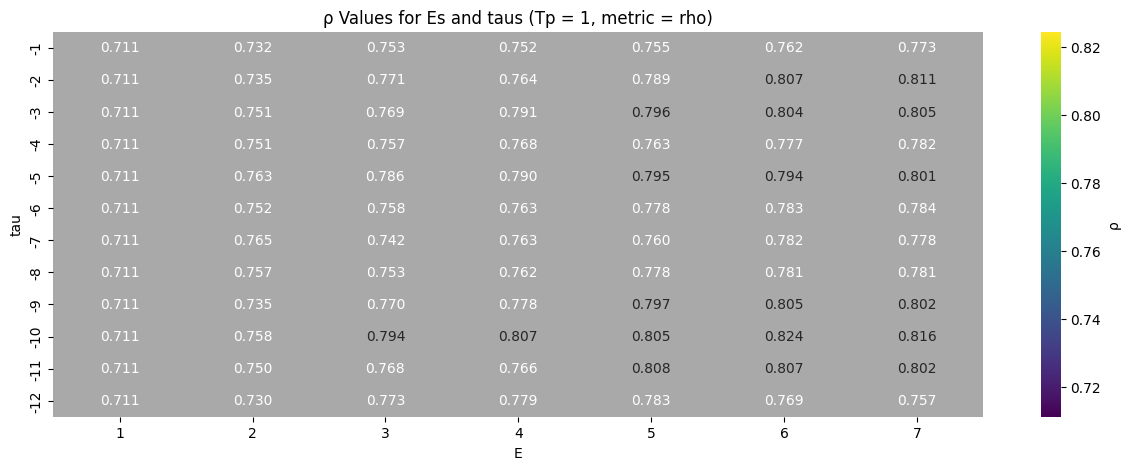

{'E_vs_tau':            1         2         3         4         5         6         7
 -1   0.71111  0.731927  0.753088  0.751693  0.754893  0.761780  0.773253
 -2   0.71111  0.734792  0.771376  0.764177  0.788703  0.806965  0.811381
 -3   0.71111  0.750519  0.769316  0.791264  0.796338  0.804005  0.805243
 -4   0.71111  0.750913  0.756762  0.767629  0.762944  0.777113  0.781634
 -5   0.71111  0.763235  0.785801  0.789742  0.795208  0.793800  0.801425
 -6   0.71111  0.752328  0.758139  0.762940  0.777670  0.782732  0.783705
 -7   0.71111  0.764894  0.742197  0.763367  0.760246  0.781551  0.778206
 -8   0.71111  0.756844  0.753223  0.762141  0.778242  0.780692  0.780731
 -9   0.71111  0.735032  0.770440  0.778355  0.796524  0.805266  0.801837
 -10  0.71111  0.757751  0.793605  0.806634  0.804987  0.824440  0.815577
 -11  0.71111  0.750437  0.768092  0.765614  0.807868  0.807360  0.802224
 -12  0.71111  0.729688  0.773235  0.778979  0.783227  0.768734  0.756589,
 'significance':      1  

In [17]:
# Example
sp = 'Planktothrix_rubescens'

# Simplex parameters
Tp = 1                               # Prediction horizon: X(t+Tp) = F(X(t))
E = list(range(1, 8))                # Embedding dimensions to search
tau = list(reversed(range(-12, 0)))  # Embedding lags to search

simplex = simplex_wrapper(
    dataFrame=data,
    columns=sp,
    target=sp,
    E=E,
    Tp=Tp,
    tau=tau,
    sig=0.05,
    metric='rho',
    figsize=(15, 5),
    decimals=3,
    showPlot=True
)

# Display simplex_wrapper output
display(simplex)

This tells us that at a timescale of Tp = 1, none of the attractor reconstructions outperform the constant predictor (the dynamics at Tp = 1 are dominated by autocorrelation).

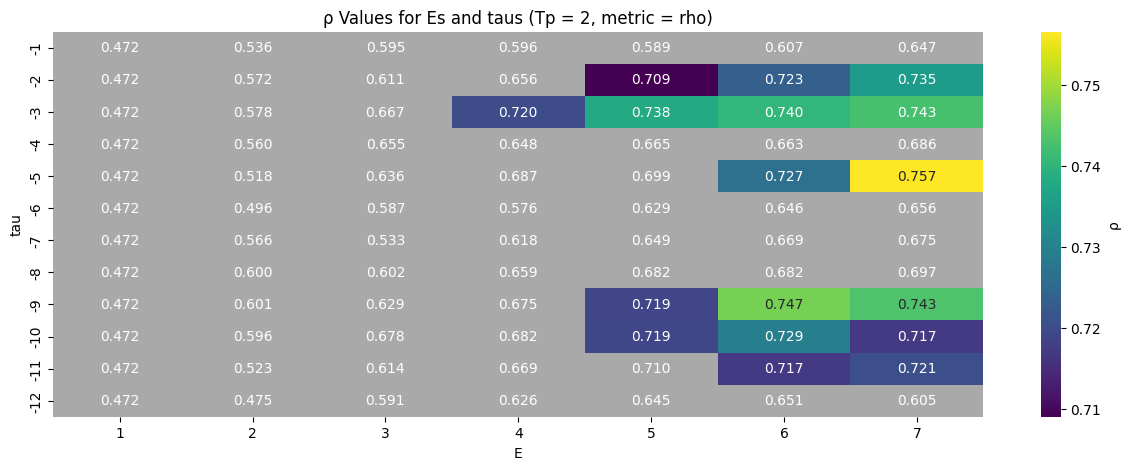

In [18]:
# Trying Tp = 2
Tp = 2

simplex = simplex_wrapper(
    dataFrame=data,
    columns=sp,
    target=sp,
    E=E,
    Tp=Tp,
    tau=tau,
    sig=0.05,
    metric='rho',
    figsize=(15, 5),
    decimals=3,
)

At a timescale of Tp = 2, we resolve attractor dynamics that allow us to do better than the constant predictor.  
We might choose E = 4, tau = -3 as the minimal (E, tau) pair that resolves the dynamics.

### Making Simplex Prediction

Passing E and tau as integers performs Simplex prediction as usual.  

The simplex_wrapper function will return a dictionary with two objects:  
'Predictions' : Simplex observations vs. predictions dataFrame  
'Summary Statistics' : rho, MAE, RMSE, % Correct Sign, N Predicted for both the Constant Predictor and Simplex

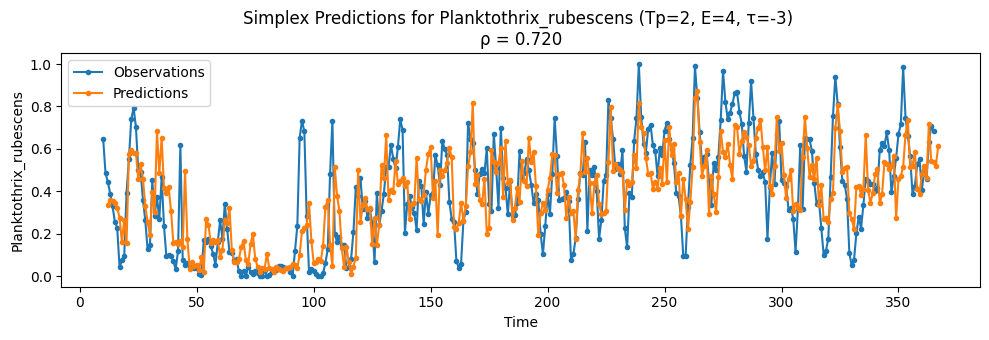

{'Predictions':       Time  Observations  Predictions  Pred_Variance
 0     10.0      0.646945          NaN            NaN
 1     11.0      0.485328          NaN            NaN
 2     12.0      0.444187     0.337056       0.054267
 3     13.0      0.389244     0.358151       0.003948
 4     14.0      0.329020     0.353657       0.005094
 ..     ...           ...          ...            ...
 353  363.0      0.631754     0.717143       0.005206
 354  364.0      0.707757     0.542324       0.011904
 355  365.0      0.685234     0.536276       0.023045
 356  366.0           NaN     0.521345       0.028231
 357  367.0           NaN     0.613833       0.075310
 
 [358 rows x 4 columns],
 'Summary Statistics':                   Simplex Constant Predictor
 rho              0.719897            0.63979
 MAE              0.131289           0.154394
 RMSE             0.169188           0.205252
 % Correct Sign  47.887324          48.169014
 N Predicted           354                354}

In [19]:
# Example

# Simplex parameters
Tp = 2
E = 4
tau = -3

simplex = simplex_wrapper(
    dataFrame=data,
    columns=sp,
    target=sp,
    E=E,
    Tp=Tp,
    tau=tau,
    metric='rho',
    showPlot=True,
)

# Display simplex_wrapper output
display(simplex)

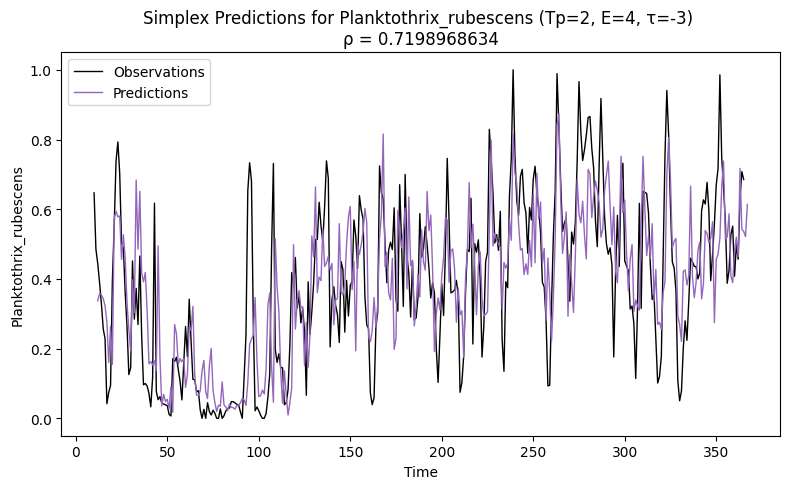

In [20]:
# You can also customize the plot (figsize, color, etc.)

simplex = simplex_wrapper(
    dataFrame=data,
    columns=sp,
    target=sp,
    E=E,
    Tp=Tp,
    tau=tau,
    metric='rho',
    showPlot=True,
    plot_kwargs={'color': ['k', 'tab:purple'], 'figsize': (8,5), 'linewidth': 1},
    decimals=10
)

## Added option to automatically handle missing values

If handleNan = True, Simplex will not choose nearest neighbors where target(t+Tp) is NaN. This allows Simplex to make more non-NaN predictions.

default pyEDM behavior:


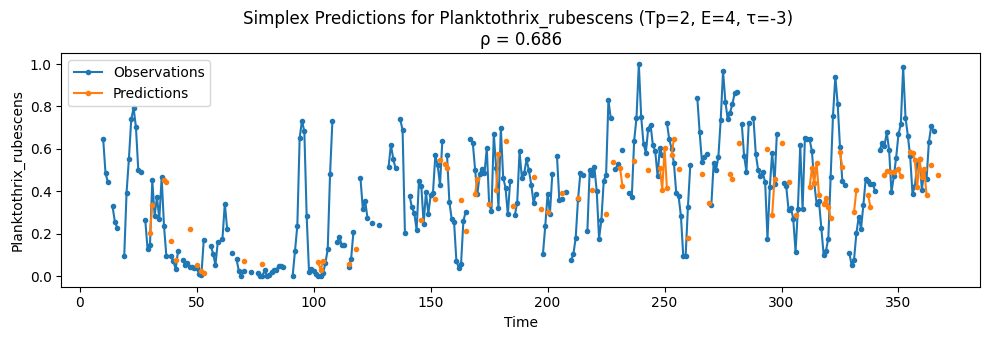

new pyEDM behavior with parameter handleNan = True (makes more successful predictions):


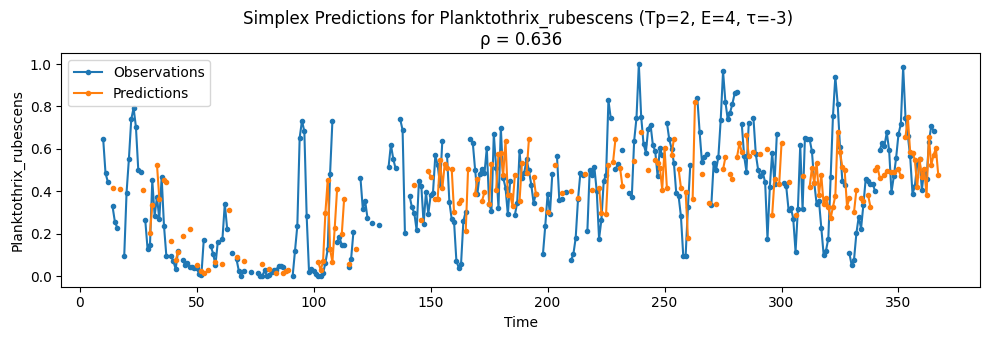

In [21]:
# Also added the option to automatically handle missing values using the validLib parameter

# Add random gaps to test
df = data.copy()
fraction = 0.15
df.loc[df.sample(frac=fraction).index, sp] = np.nan

print('default pyEDM behavior:')
# handleNan = False
simplex = simplex_wrapper(
    dataFrame=df,
    columns=sp,
    target=sp,
    E=E,
    Tp=Tp,
    tau=tau,
    handleNan=False,
    metric='rho',
    showPlot=True,
)

print('new pyEDM behavior with parameter handleNan = True (makes more successful predictions):')
# handleNan = True
simplex = simplex_wrapper(
    dataFrame=df,
    columns=sp,
    target=sp,
    E=E,
    Tp=Tp,
    tau=tau,
    handleNan=True,
    metric='rho',
    showPlot=True,
)

### Behavior when cross-mapping

When cross-mapping there's no equivalent to a constant predictor, so it doesn't do the significance test.

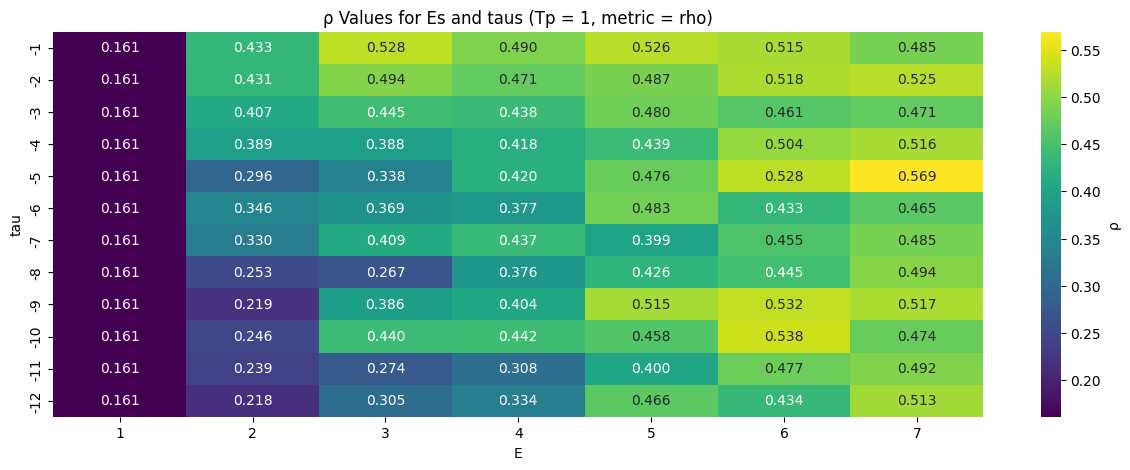

{'E_vs_tau':             1         2         3         4         5         6         7
 -1   0.161428  0.433226  0.528149  0.489619  0.525900  0.515006  0.484680
 -2   0.161428  0.431124  0.493677  0.470684  0.487026  0.518412  0.524580
 -3   0.161428  0.406616  0.444504  0.437645  0.479635  0.461225  0.471238
 -4   0.161428  0.388506  0.388020  0.418005  0.438535  0.504138  0.515594
 -5   0.161428  0.295958  0.338205  0.420182  0.476484  0.528414  0.568989
 -6   0.161428  0.346350  0.369113  0.377013  0.482679  0.433312  0.464901
 -7   0.161428  0.329689  0.409044  0.436715  0.398928  0.455486  0.485037
 -8   0.161428  0.253469  0.267197  0.376141  0.426275  0.444830  0.494388
 -9   0.161428  0.218913  0.385941  0.404493  0.514735  0.531703  0.516604
 -10  0.161428  0.246384  0.439867  0.442068  0.458453  0.538096  0.474042
 -11  0.161428  0.239033  0.274297  0.307692  0.400296  0.476687  0.492248
 -12  0.161428  0.218291  0.305236  0.334193  0.465570  0.433718  0.512737,
 'significan

In [26]:
# Example
sp1 = 'Planktothrix_rubescens'
sp2 = 'Aphanizomenon_flos-aquae'

# Simplex parameters
Tp = 1                               # Prediction horizon: X(t+Tp) = F(X(t))
E = list(range(1, 8))                # Embedding dimensions to search
tau = list(reversed(range(-12, 0)))  # Embedding lags to search

simplex = simplex_wrapper(
    dataFrame=data,
    columns=sp2,
    target=sp1,
    E=E,
    Tp=Tp,
    tau=tau,
    sig=0.05,
    metric='rho',
    figsize=(15, 5),
    decimals=3,
    showPlot=True
)

# Display simplex_wrapper output
display(simplex)